# **From Passenger Voice to Operational Intelligence: A Transformer-Based NLP System for Airline Experience Analysis - NLP**

# Part 1 - Business problem

The global aviation industry processes millions of passenger reviews annually across dozens of carriers, routes, cabin classes, and aircraft types. While structured rating fields (seat comfort, cabin staff, food, entertainment, ground service, wifi, and value for money) provide a quantifiable snapshot of the passenger experience, the most actionable intelligence remains locked inside free-text reviews — unstructured, high-volume, and impossible to analyze at scale through manual processes.

Airlines and aviation consultancies currently face three compounding challenges. First, numeric ratings alone fail to explain *why* a passenger felt underserved — a 2-star cabin staff score carries no operational signal without the accompanying narrative. Second, optional rating fields such as Wifi & Connectivity and Inflight Entertainment exhibit high missingness rates, creating blind spots in service benchmarking. Third, the final recommendation indicator (Yes/No) is absent from reviews collected on third-party platforms, limiting the reach of any satisfaction model trained solely on proprietary data.

This project proposes the development of a **Transformer-based NLP intelligence system** applied to the Global Airline Reviews dataset, spanning airlines from A to Z across all major cabin classes and traveller profiles. The system is designed to serve a customer experience consultancy delivering automated, scalable insights to airline operations, product, and marketing teams.

Four modeling tasks are addressed. The first is a **recommendation classifier** — given the review title and full text, predict whether the passenger would recommend the airline, enabling inference on external review platforms where the structured label is unavailable. The second is a **value-for-money predictor** — using review text combined with seat type and traveller category, estimate the passenger's cost-benefit perception, surfacing pricing and communication misalignments by cabin class. The third is an **abstractive summarization engine** — given a batch of reviews grouped by airline and time window, generate an executive briefing of the main positive and negative signals, replacing manual monthly CX reporting. The fourth is an **aspect-based sentiment analysis pipeline** — extract which specific service dimensions (staff, food, seat, entertainment, ground, wifi) appear as problems or highlights in the review text, even when the corresponding numeric rating field is missing or null.

The core justification for Transformer architectures across all four tasks lies in the linguistic complexity of passenger reviews. Negation, contrast, and irony are structurally common in this domain — a review may praise the cabin crew while condemning the boarding process in the same sentence, a pattern that bag-of-words and TF-IDF baselines cannot resolve. Additionally, the international reviewer base introduces latent multilingual variation that cross-lingual models such as XLM-RoBERTa are specifically designed to handle. BERT and RoBERTa will serve the classification and extraction tasks, BART and T5 will serve the summarization task, and all Transformer models will be benchmarked against classical baselines to quantify the real performance gain of contextual representations over frequency-based approaches.

The expected deliverable is a modular, end-to-end NLP pipeline that converts raw passenger text into structured, actionable intelligence — segmented by airline, route, aircraft model, cabin class, and traveller type — and ready for integration into an operational dashboard for aviation CX teams.

**Pt-br**

**Problema de Negócio — Global Airline Reviews**

Aqui está uma proposta sólida de problema de negócio que justifica o uso de Transformers de forma natural e bem motivada:

**Problema Central**

**"Inteligência de Experiência do Passageiro: da Voz do Cliente à Ação Operacional"**

Companhias aéreas recebem **milhares de avaliações mensais**, mas a maior parte do valor está presa no texto livre — impossível de escalar com análise manual. Os ratings numéricos capturam *o quê* o cliente avaliou, mas não *por quê*. O gap entre os dois é onde mora o problema.

**Contexto de Negócio**

Uma consultoria de *Customer Experience* para o setor de aviação precisa entregar um **sistema inteligente de análise de reviews** para um consórcio de companhias aéreas. O objetivo é transformar o feedback textual bruto em **sinais acionáveis** para as equipes de operações, produto e marketing — sem depender de análise manual.

**Tarefas de Modelagem (onde entram os Transformers)**

**Tarefa 1 — Classificação de Recomendação `(BERT / RoBERTa)`**

> **"A partir do texto da review, o passageiro recomendaria a companhia?"**

- **Input:** `Title` + `Review` (texto livre)
- **Output:** `Recommended` (Yes / No)
- **Modelo:** Fine-tuning de `bert-base-uncased` ou `roberta-base`
- **Justificativa de negócio:** Permite processar reviews em plataformas externas (TripAdvisor, Google) onde o campo *Recommended* não existe — expandindo o alcance da análise além do dataset proprietário.
- **Baseline:** TF-IDF + Logistic Regression (para medir o ganho real do Transformer)

**Tarefa 2 — Predição de Value for Money `(RoBERTa / DistilBERT)`**

> **"O texto da review consegue prever a percepção de custo-benefício — mesmo quando os ratings individuais são bons?"**

- **Input:** `Review` + `Seat Type` + `Type Of Traveller`
- **Output:** `Value For Money` (1–5, regressão ou classificação ordinal)
- **Modelo:** `roberta-base` com cabeça de regressão / classificação ordinal
- **Justificativa de negócio:** Detecta **desalinhamento de expectativa × preço** por classe de cabine — insight direto para estratégia de precificação e comunicação de produto.

**Tarefa 3 — Geração de Resumo Executivo por Companhia `(BART / T5)`**

> **"Dado um conjunto de reviews de uma companhia em um período, gere um resumo executivo dos principais pontos positivos e negativos."**

- **Input:** Conjunto de `Review` agrupados por `NAMES` + `Date`
- **Output:** Texto resumido (abstractive summarization)
- **Modelo:** `facebook/bart-large-cnn` ou `t5-base` fine-tuned
- **Justificativa de negócio:** Substitui relatórios mensais manuais de CX — o time de operações recebe um briefing automático por companhia, pronto para apresentação executiva.

**Tarefa 4 — Extração de Aspectos Negativos `(BERT + NER / Span Extraction)`**

> **"Quais dimensões da experiência (staff, comida, assento, entretenimento) aparecem como problemas no texto — mesmo quando o rating numérico está ausente ou omitido?"**

- **Input:** `Review`
- **Output:** Aspectos identificados + polaridade (Aspect-Based Sentiment Analysis)
- **Modelo:** `bert-base-uncased` com cabeça de span extraction ou token classification
- **Justificativa de negócio:** Preenche o gap dos ratings faltantes (Wifi & Connectivity e Inflight Entertainment têm alta taxa de campos vazios) e gera granularidade além dos 6 eixos do dataset.

**Arquitetura Geral do Sistema**

```
Reviews (texto bruto)
        │
        ▼
┌───────────────────────┐
│  Pré-processamento    │  limpeza, idioma, verificação
└───────────┬───────────┘
            │
     ┌──────┴──────┐
     ▼             ▼
[BERT/RoBERTa] [BART/T5]
Classificação  Sumarização
Recomendação   Executiva
Value for Money
ABSA
     │
     ▼
Dashboard Operacional
(por companhia / rota / cabine / período)
```

**Métricas de Avaliação**

| Tarefa | Métrica Principal | Métrica Secundária |
|---|---|---|
| Recomendação | F1-Score (macro) | ROC-AUC |
| Value for Money | MAE / QWK | Pearson r |
| Sumarização | ROUGE-L | BERTScore |
| ABSA | F1 por aspecto | Accuracy |

**Diferenciais que Justificam Transformers**

- Reviews são **contexto-dependentes** — "o staff foi atencioso *apesar do atraso*" exige compreensão de relações semânticas longas
- Negação e ironia são comuns em avaliações negativas — modelos bag-of-words falham sistematicamente
- Multilinguismo latente no dataset (reviewers de países não-anglófonos) — modelos como `xlm-roberta-base` podem ser explorados
- Sumarização abstractiva é **impossível** com abordagens clássicas.

In [2]:
!pip install vaderSentiment
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.7 MB/s eta 0:00:00


In [3]:
# Basic libraries
import pandas as pd
import numpy as np

# Regular expressions, token handling, progress bar
import re
from collections import Counter
from itertools import chain
from tqdm.notebook import tqdm

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Feature extraction
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Dimensionality reduction
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Pipeline and data preparation
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Machine Learning models
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Additional metrics
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Progress bar
from tqdm.notebook import tqdm

# NLP libraries
import re
import emoji
import nltk
from nltk import ngrams
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Sentiment analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


# Part 2 - Database

In [4]:
train = pd.read_excel("/kaggle/input/datasets/rosemeenshaikh/global-airline-reviews/Airline_Reviews_Combined.xlsx")
train

,NAMES,Title,Author,Country,Date,Verified,Review,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended,Aircraft
0,AB Aviation,"""pretty decent airline""",Tom Hansen,Netherlands,11th November 2019,True,✅Trip Verified| Moroni to Moheli. Turned out ...,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,NaN,4.0,NaN,3.0,yes,NaN
1,AB Aviation,"""Not a good airline""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Moroni to Anjouan. It is a ver...,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,NaN,1.0,NaN,2.0,no,E120
2,AB Aviation,"""flight was fortunately short""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,NaN,1.0,NaN,2.0,no,Embraer E120
3,Adria Airways,"""I will never fly again with Adria""",D Praetextatus,Serbia,28th September 2019,False,Not Verified| Please do a favor yourself and ...,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no,NaN
4,Adria Airways,"""it ruined our last days of holidays""",D Meijer,Netherlands,24th September 2019,True,✅Trip Verified| Do not book a flight with this...,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7725,ZIPAIR,"""presented me with a handmade birthday card""",K Thompson,United States,20th July 2024,True,✅Trip Verified| My family and I flew Zipair fr...,Family Leisure,Economy Class,Tokyo to Vancouver,July 2024,3.0,5.0,NaN,NaN,4.0,NaN,4.0,yes,B787/900
7726,ZIPAIR,"""a great airline""",E Fusselman,United States,28th June 2024,False,Not Verified| This was a great airline. All ...,Family Leisure,Economy Class,San Francisco to Tokyo Narita,June 2024,5.0,5.0,NaN,NaN,5.0,3.0,5.0,yes,Boeing 787
7727,ZIPAIR,"""forced to check my carry-on""",Michelle Rice,United States,18th June 2024,True,"✅Trip Verified| The flight was fine. However,...",Solo Leisure,Economy Class,Los Angeles to Tokyo Narita,June 2024,3.0,4.0,NaN,NaN,4.0,1.0,4.0,no,NaN
7728,ZIPAIR,"""attendants were polite and respectful""",Deborah Kenehan,United States,26th May 2024,False,Not Verified| ZIPAIR flight 24 from Tokyo to...,Family Leisure,Economy Class,Los Angeles to Tokyo,May 2024,5.0,5.0,5.0,5.0,5.0,5.0,5.0,yes,Boeing 787


In [5]:
train.head()

,NAMES,Title,Author,Country,Date,Verified,Review,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Inflight Entertainment,Ground Service,Wifi & Connectivity,Value For Money,Recommended,Aircraft
0,AB Aviation,"""pretty decent airline""",Tom Hansen,Netherlands,11th November 2019,True,✅Trip Verified| Moroni to Moheli. Turned out ...,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,NaN,4.0,NaN,3.0,yes,NaN
1,AB Aviation,"""Not a good airline""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Moroni to Anjouan. It is a ver...,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,NaN,1.0,NaN,2.0,no,E120
2,AB Aviation,"""flight was fortunately short""",Gyan Fernando,United Kingdom,25th June 2019,True,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,NaN,1.0,NaN,2.0,no,Embraer E120
3,Adria Airways,"""I will never fly again with Adria""",D Praetextatus,Serbia,28th September 2019,False,Not Verified| Please do a favor yourself and ...,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,NaN,1.0,NaN,1.0,no,NaN
4,Adria Airways,"""it ruined our last days of holidays""",D Meijer,Netherlands,24th September 2019,True,✅Trip Verified| Do not book a flight with this...,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no,NaN


In [6]:
print("Training set size:", train.shape)

Training set size: (7730, 20)


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7730 entries, 0 to 7729
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   NAMES                   7730 non-null   object 
 1   Title                   7610 non-null   object 
 2   Author                  7730 non-null   object 
 3   Country                 7477 non-null   object 
 4   Date                    7730 non-null   object 
 5   Verified                7730 non-null   bool   
 6   Review                  7730 non-null   object 
 7   Type Of Traveller       6930 non-null   object 
 8   Seat Type               7437 non-null   object 
 9   Route                   6896 non-null   object 
 10  Date Flown              6926 non-null   object 
 11  Seat Comfort            6501 non-null   float64
 12  Cabin Staff Service     6455 non-null   float64
 13  Food & Beverages        4785 non-null   float64
 14  Inflight Entertainment  3159 non-null   

In [8]:
train.dtypes

NAMES                      object
Title                      object
Author                     object
Country                    object
Date                       object
Verified                     bool
Review                     object
Type Of Traveller          object
Seat Type                  object
Route                      object
Date Flown                 object
Seat Comfort              float64
Cabin Staff Service       float64
Food & Beverages          float64
Inflight Entertainment    float64
Ground Service            float64
Wifi & Connectivity       float64
Value For Money           float64
Recommended                object
Aircraft                   object
dtype: object

# Part 3 - Preprocessing

# Part 3.1 - Pre-processing

In [9]:
def preprocess_text(text):
    """
    Function for preprocessing airline review text.
    Input: string (passenger review)
    Output: cleaned and normalized string
    """
    # Remove emojis and unicode symbols
    text = emoji.replace_emoji(str(text), replace='')
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    
    # Remove numbers
    text = re.sub(r'\d+', '', text)
   
    # Remove punctuation and special characters
    text = re.sub(r'[^\w\s]', '', text)
   
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords and short words
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    
    # Return cleaned text
    return " ".join(tokens)

In [10]:
# Apply preprocessing
tqdm.pandas()
train["clean_text"] = train["Review"].progress_apply(preprocess_text)

# Display sample
train[["Review", "clean_text"]].head(10)

  0%|          | 0/7730 [00:00<?, ?it/s]

,Review,clean_text
0,✅Trip Verified| Moroni to Moheli. Turned out ...,trip verified moroni moheli turned pretty dece...
1,✅Trip Verified| Moroni to Anjouan. It is a ver...,trip verified moroni anjouan small airline tic...
2,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,trip verified anjouan dzaoudzi small airline a...
3,Not Verified| Please do a favor yourself and ...,verified please favor fly adria route munich p...
4,✅Trip Verified| Do not book a flight with this...,trip verified book flight airline friend retur...
5,✅Trip Verified| Had very bad experience with ...,trip verified bad experience rerouted cancelle...
6,"Not Verified| Ljubljana to Zürich. Firstly, L...",verified ljubljana zürich firstly ljubljana ai...
7,"Not Verified| First of all, I am not complain...",verified first complaining specific flight luf...
8,✅Trip Verified| Worst Airline ever! They comb...,trip verified worst airline ever combined two ...
9,✅Trip Verified| Ljubljana to Munich. The homeb...,trip verified ljubljana munich homebase airpor...


# Part 3.2 - Tokenization

In [11]:
def tokenize_texts_nltk(texts):
    """
    Tokenizes a list of texts using NLTK with a progress bar (tqdm).

    Parameters:
    - texts: list or pandas Series of preprocessed text strings

    Returns:
    - list of token lists
    """
    tokenized_texts = []
    
    # tqdm displays iteration progress
    for text in tqdm(texts, desc="Tokenizing texts", total=len(texts)):
        tokens = word_tokenize(str(text))
        tokens = [t for t in tokens if len(t) > 1]  # ignore tokens with only 1 character
        tokenized_texts.append(tokens)
        
    return tokenized_texts

# Apply the function
tokenized_texts = tokenize_texts_nltk(train["clean_text"])

print("Example of tokenization:")
for i, tokens in enumerate(tokenized_texts[:10]):
    print(f"Post {i+1}:", tokens)

Tokenizing texts:   0%|          | 0/7730 [00:00<?, ?it/s]

Example of tokenization:
Post 1: ['trip', 'verified', 'moroni', 'moheli', 'turned', 'pretty', 'decent', 'airline', 'online', 'booking', 'worked', 'well', 'checkin', 'boarding', 'fine', 'plane', 'looked', 'well', 'maintained', 'short', 'flight', 'minutes', 'didnt', 'expect', 'much', 'still', 'managed', 'hand', 'bottle', 'water', 'biscuits', 'though', 'nice', 'flights', 'time']
Post 2: ['trip', 'verified', 'moroni', 'anjouan', 'small', 'airline', 'ticket', 'advised', 'turn', 'hrs', 'confusion', 'small', 'airport', 'directed', 'office', 'aviation', 'still', 'closed', 'opened', 'hrs', 'told', 'flight', 'put', 'back', 'hrs', 'tried', 'contact', 'could', 'true', 'phone', 'number', 'local', 'guide', 'informed', 'either', 'presume', 'bumped', 'later', 'flight', 'operate', 'usual', 'confusion', 'checkin', 'flight', 'mins', 'problems', 'good', 'airline', 'one', 'comoros']
Post 3: ['trip', 'verified', 'anjouan', 'dzaoudzi', 'small', 'airline', 'airline', 'based', 'comoros', 'checkin', 'disorganis

In [12]:
# 'tokens' 
from tqdm.notebook import tqdm
tqdm.pandas()

# Apply tokenization with progress bar
train["tokens"] = train["clean_text"].progress_apply(lambda x: word_tokenize(str(x)))

# Remove tokens with only one character (optional)
train["tokens"] = train["tokens"].apply(lambda tokens: [t for t in tokens if len(t) > 1])

# Display sample
train[["clean_text", "tokens"]].head(20)

  0%|          | 0/7730 [00:00<?, ?it/s]

,clean_text,tokens
0,trip verified moroni moheli turned pretty dece...,"[trip, verified, moroni, moheli, turned, prett..."
1,trip verified moroni anjouan small airline tic...,"[trip, verified, moroni, anjouan, small, airli..."
2,trip verified anjouan dzaoudzi small airline a...,"[trip, verified, anjouan, dzaoudzi, small, air..."
3,verified please favor fly adria route munich p...,"[verified, please, favor, fly, adria, route, m..."
4,trip verified book flight airline friend retur...,"[trip, verified, book, flight, airline, friend..."
5,trip verified bad experience rerouted cancelle...,"[trip, verified, bad, experience, rerouted, ca..."
6,verified ljubljana zürich firstly ljubljana ai...,"[verified, ljubljana, zürich, firstly, ljublja..."
7,verified first complaining specific flight luf...,"[verified, first, complaining, specific, fligh..."
8,trip verified worst airline ever combined two ...,"[trip, verified, worst, airline, ever, combine..."
9,trip verified ljubljana munich homebase airpor...,"[trip, verified, ljubljana, munich, homebase, ..."


# Part 3.3 - Lemmatization

In [13]:
def lemmatize_texts_nltk(tokenized_texts):
    """
    Applies lemmatization to a list of token lists using NLTK.
    
    Parameters:
    - tokenized_texts: list of token lists (e.g., [['liking', 'post'], ['loving', 'promotion']])
    
    Returns:
    - list of lemmatized token lists
    """
    lemmatizer = WordNetLemmatizer()
    lemmatized_texts = []
    
    for tokens in tqdm(tokenized_texts, desc="Lemmatizing texts", total=len(tokenized_texts)):
        lemmas = [lemmatizer.lemmatize(t) for t in tokens]
        lemmatized_texts.append(lemmas)
    
    return lemmatized_texts

# Apply lemmatization to the 'tokens' column
train["lemmas"] = lemmatize_texts_nltk(train["tokens"])

# Display sample
train[["tokens", "lemmas"]].head(30)

Lemmatizing texts:   0%|          | 0/7730 [00:00<?, ?it/s]

,tokens,lemmas
0,"[trip, verified, moroni, moheli, turned, prett...","[trip, verified, moroni, moheli, turned, prett..."
1,"[trip, verified, moroni, anjouan, small, airli...","[trip, verified, moroni, anjouan, small, airli..."
2,"[trip, verified, anjouan, dzaoudzi, small, air...","[trip, verified, anjouan, dzaoudzi, small, air..."
3,"[verified, please, favor, fly, adria, route, m...","[verified, please, favor, fly, adria, route, m..."
4,"[trip, verified, book, flight, airline, friend...","[trip, verified, book, flight, airline, friend..."
5,"[trip, verified, bad, experience, rerouted, ca...","[trip, verified, bad, experience, rerouted, ca..."
6,"[verified, ljubljana, zürich, firstly, ljublja...","[verified, ljubljana, zürich, firstly, ljublja..."
7,"[verified, first, complaining, specific, fligh...","[verified, first, complaining, specific, fligh..."
8,"[trip, verified, worst, airline, ever, combine...","[trip, verified, worst, airline, ever, combine..."
9,"[trip, verified, ljubljana, munich, homebase, ...","[trip, verified, ljubljana, munich, homebase, ..."


# Part 3.4 - Bigrams

In [14]:
def generate_ngrams(tokenized_texts, n=2):
    """
    Generates n-grams from a list of token lists.
    
    Parameters:
    - tokenized_texts: list of token lists (e.g., [['exclusive', 'promotion'], ['new', 'collection']])
    - n: size of the n-gram (1 = unigrams, 2 = bigrams, 3 = trigrams, etc.)
    
    Returns:
    - list of lists of n-grams (each n-gram is a string joined by spaces)
    """
    ngram_texts = []
    
    for tokens in tqdm(tokenized_texts, desc=f"Generating {n}-grams", total=len(tokenized_texts)):
        ngram_list = list(ngrams(tokens, n))
        ngram_strings = [" ".join(gram) for gram in ngram_list]
        ngram_texts.append(ngram_strings)
    
    return ngram_texts

In [15]:
# Generate bigrams (pairs of words)
train["bigrams"] = generate_ngrams(train["tokens"], n=2)

# Generate trigrams
train["trigrams"] = generate_ngrams(train["tokens"], n=3)

# Display sample
train[["tokens", "bigrams", "trigrams"]].head(20)

Generating 2-grams:   0%|          | 0/7730 [00:00<?, ?it/s]

Generating 3-grams:   0%|          | 0/7730 [00:00<?, ?it/s]

,tokens,bigrams,trigrams
0,"[trip, verified, moroni, moheli, turned, prett...","[trip verified, verified moroni, moroni moheli...","[trip verified moroni, verified moroni moheli,..."
1,"[trip, verified, moroni, anjouan, small, airli...","[trip verified, verified moroni, moroni anjoua...","[trip verified moroni, verified moroni anjouan..."
2,"[trip, verified, anjouan, dzaoudzi, small, air...","[trip verified, verified anjouan, anjouan dzao...","[trip verified anjouan, verified anjouan dzaou..."
3,"[verified, please, favor, fly, adria, route, m...","[verified please, please favor, favor fly, fly...","[verified please favor, please favor fly, favo..."
4,"[trip, verified, book, flight, airline, friend...","[trip verified, verified book, book flight, fl...","[trip verified book, verified book flight, boo..."
5,"[trip, verified, bad, experience, rerouted, ca...","[trip verified, verified bad, bad experience, ...","[trip verified bad, verified bad experience, b..."
6,"[verified, ljubljana, zürich, firstly, ljublja...","[verified ljubljana, ljubljana zürich, zürich ...","[verified ljubljana zürich, ljubljana zürich f..."
7,"[verified, first, complaining, specific, fligh...","[verified first, first complaining, complainin...","[verified first complaining, first complaining..."
8,"[trip, verified, worst, airline, ever, combine...","[trip verified, verified worst, worst airline,...","[trip verified worst, verified worst airline, ..."
9,"[trip, verified, ljubljana, munich, homebase, ...","[trip verified, verified ljubljana, ljubljana ...","[trip verified ljubljana, verified ljubljana m..."


# Part 3.5 - Number of words per text

In [16]:
# Function to count the number of words per text
from tqdm import tqdm

def count_words(tokenized_texts):
    """
    Counts the number of words in each token list.
    
    Parameters:
    - tokenized_texts: list of token lists (e.g., [['exclusive', 'promotion'], ['new', 'collection']])
    
    Returns:
    - list with the number of words in each text
    """
    counts = []
    for tokens in tqdm(tokenized_texts, desc="Counting words", total=len(tokenized_texts)):
        counts.append(len(tokens))
    return counts

# Create a column with the word count
train["word_count"] = count_words(train["tokens"])

# Display sample
train[["clean_text", "word_count"]].head(10)

Counting words: 100%|██████████| 7730/7730 [00:00<00:00, 2567060.17it/s]


,clean_text,word_count
0,trip verified moroni moheli turned pretty dece...,35
1,trip verified moroni anjouan small airline tic...,50
2,trip verified anjouan dzaoudzi small airline a...,38
3,verified please favor fly adria route munich p...,63
4,trip verified book flight airline friend retur...,52
5,trip verified bad experience rerouted cancelle...,69
6,verified ljubljana zürich firstly ljubljana ai...,32
7,verified first complaining specific flight luf...,90
8,trip verified worst airline ever combined two ...,23
9,trip verified ljubljana munich homebase airpor...,38


# Part 3.6 - VADER Classification Sentiment

In [17]:
def analyze_sentiments_vader(texts):
    """
    Applies sentiment analysis with VADER on a list of texts.
    
    Parameters:
    - texts: list or pandas Series of strings (original or cleaned messages)
    
    Returns:
    - DataFrame with sentiment scores (pos, neu, neg, compound)
    - And an overall sentiment classification: 'positive', 'negative', or 'neutral'
    """
    analyzer = SentimentIntensityAnalyzer()
    results = []

    for text in tqdm(texts, desc="Analyzing sentiments", total=len(texts)):
        score = analyzer.polarity_scores(str(text))
        compound = score["compound"]
        
        if compound >= 0.05:
            sentiment = "positive"
        elif compound <= -0.05:
            sentiment = "negative"
        else:
            sentiment = "neutral"
        
        results.append({
            "positive": score["pos"],
            "neutral": score["neu"],
            "negative": score["neg"],
            "compound": compound,
            "sentiment": sentiment
        })
    
    return pd.DataFrame(results)

In [18]:
# Apply VADER on the original or cleaned text
df_sent = analyze_sentiments_vader(train["clean_text"])

# Merge sentiment columns into the main DataFrame
train = pd.concat([train, df_sent], axis=1)

# Display sample
train[["clean_text", "compound", "sentiment"]].head(20)

Analyzing sentiments: 100%|██████████| 7730/7730 [00:03<00:00, 2374.70it/s]


,clean_text,compound,sentiment
0,trip verified moroni moheli turned pretty dece...,0.9217,positive
1,trip verified moroni anjouan small airline tic...,-0.0258,neutral
2,trip verified anjouan dzaoudzi small airline a...,0.8122,positive
3,verified please favor fly adria route munich p...,-0.8993,negative
4,trip verified book flight airline friend retur...,0.4588,positive
5,trip verified bad experience rerouted cancelle...,-0.6808,negative
6,verified ljubljana zürich firstly ljubljana ai...,-0.9524,negative
7,verified first complaining specific flight luf...,-0.7090,negative
8,trip verified worst airline ever combined two ...,-0.2263,negative
9,trip verified ljubljana munich homebase airpor...,0.6595,positive


# Part 3.7 - Score (VADER)

In [19]:
def get_sentiment_score(texts, metric="compound", normalize=False):
    """
    Calculates a single VADER sentiment score per text.
    
    Parameters:
    - texts: list or pd.Series containing text messages
    - metric: 'compound' | 'positive' | 'neutral' | 'negative'
              (default: 'compound')
    - normalize: if True, applies min-max normalization to [0, 1]
    
    Returns:
    - pd.Series named 'sentiment_score'
    """
    mapping = {
        "positive": "pos",
        "neutral": "neu",
        "negative": "neg",
        "compound": "compound"
    }
    
    metric = metric.lower()
    if metric not in mapping:
        raise ValueError("Invalid metric. Use: 'compound', 'positive', 'neutral', or 'negative'.")
    
    analyzer = SentimentIntensityAnalyzer()
    values = []

    for txt in tqdm(texts, desc="Calculating sentiment_score", total=len(texts)):
        s = analyzer.polarity_scores(str(txt))[mapping[metric]]
        values.append(s)

    series = pd.Series(values, name="sentiment_score")

    if normalize:
        vmin, vmax = series.min(), series.max()
        if vmax > vmin:
            series = (series - vmin) / (vmax - vmin)
        else:
            series = series * 0.0  # all equal values

    return series

# Column with the compound (default)
train["sentiment_score"] = get_sentiment_score(train["clean_text"])

# Display sample
train[["clean_text", "sentiment", "sentiment_score"]].head(n=10)

Calculating sentiment_score: 100%|██████████| 7730/7730 [00:03<00:00, 2407.68it/s]


,clean_text,sentiment,sentiment_score
0,trip verified moroni moheli turned pretty dece...,positive,0.9217
1,trip verified moroni anjouan small airline tic...,neutral,-0.0258
2,trip verified anjouan dzaoudzi small airline a...,positive,0.8122
3,verified please favor fly adria route munich p...,negative,-0.8993
4,trip verified book flight airline friend retur...,positive,0.4588
5,trip verified bad experience rerouted cancelle...,negative,-0.6808
6,verified ljubljana zürich firstly ljubljana ai...,negative,-0.9524
7,verified first complaining specific flight luf...,negative,-0.7090
8,trip verified worst airline ever combined two ...,negative,-0.2263
9,trip verified ljubljana munich homebase airpor...,positive,0.6595


# Part 4 - Data Cleaning

In [20]:
# Function for cleaning the Facebook dataset

# enables progress bar for apply()
tqdm.pandas()  

def clean_dataset(df):
    """
    Performs general DataFrame cleaning with tqdm progress bar:
    - Removes duplicates
    - Removes empty or null text rows
    - Cleans the 'message' column (removes URLs, extra spaces, etc.)
    - Resets the index
    
    Returns:
    - Cleaned DataFrame
    """
    df = df.copy()
       
    # Remove rows with null or empty 'message'
    df = df[df["clean_text"].notnull()]
    df = df[df["clean_text"].str.strip() != ""]
    
    # Internal function for basic text cleaning
    def basic_text_clean(text):
        text = str(text).lower()
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove URLs
        text = re.sub(r"<.*?>", "", text)                    # remove HTML tags
        text = re.sub(r"\s+", " ", text).strip()             # remove multiple spaces
        return text

    # Apply cleaning with progress bar
    df["clean_text"] = df["clean_text"].progress_apply(basic_text_clean)
    
    # Fill missing values in other columns
    df.fillna({
        "media_type": "unknown",
        "link_name": "no_link",
        "link": "no_link",
    }, inplace=True)
    
    # Reset index
    df.reset_index(drop=True, inplace=True)
    
    return df

# Apply cleaning to train and test datasets
train = clean_dataset(train)

# Display dataset info
print("Rows after cleaning:", len(train))

100%|██████████| 7730/7730 [00:00<00:00, 32984.15it/s]

Rows after cleaning: 7730


In [21]:
# Function for cleaning data with tqdm and column removal

# enables progress bar for apply()
tqdm.pandas()  

def clean_dataset(df):
    """
    Performs general DataFrame cleaning:
    - Removes duplicates
    - Removes empty or null text rows
    - Cleans the 'message' column (removes URLs, extra spaces, etc.)
    - Drops unnecessary columns
    - Resets the index
    
    Returns:
    - Cleaned and reduced DataFrame
    """
    df = df.copy()
       
    # Remove rows with null or empty 'message'
    df = df[df["clean_text"].notnull()]
    df = df[df["clean_text"].str.strip() != ""]
    
    # Internal function for basic text cleaning
    def basic_text_clean(text):
        text = str(text).lower()
        text = re.sub(r"http\S+|www\S+|https\S+", "", text)  # remove URLs
        text = re.sub(r"<.*?>", "", text)                    # remove HTML tags
        text = re.sub(r"\s+", " ", text).strip()             # remove multiple spaces
        return text

    # Apply cleaning with progress bar
    df["clean_text"] = df["clean_text"].progress_apply(basic_text_clean)
    
    # Drop unnecessary columns
    drop_cols = [
        "Title", "Author", "Country", 
        "Date", "Verified", "Date", "Flown",
        "Seat", "Comfort",	"Cabin", "Staff", "Service", "Date Flown", "Food & Beverages",
        "Inflight", "Entertainment",	"Seat Comfort", "Ground Service",	"Wifi & Connectivity",	"Value For Money", "Cabin Staff Service",
    "Inflight Entertainment", "Recommended", "Route", "Seat Type", "Type Of Traveller"]
    
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
    
    # Fill remaining missing values
    df.fillna({
        "media_type": "unknown"
    }, inplace=True)
    
    # Reset index
    df.reset_index(drop=True, inplace=True)
    
    return df

# Apply cleaning to train and test datasets
train = clean_dataset(train)

# Display cleaned dataset
train.head(5)

100%|██████████| 7730/7730 [00:00<00:00, 32401.69it/s]


,NAMES,Review,Aircraft,clean_text,tokens,lemmas,bigrams,trigrams,word_count,positive,neutral,negative,compound,sentiment,sentiment_score
0,AB Aviation,✅Trip Verified| Moroni to Moheli. Turned out ...,NaN,trip verified moroni moheli turned pretty dece...,"[trip, verified, moroni, moheli, turned, prett...","[trip, verified, moroni, moheli, turned, prett...","[trip verified, verified moroni, moroni moheli...","[trip verified moroni, verified moroni moheli,...",35,0.344,0.656,0.000,0.9217,positive,0.9217
1,AB Aviation,✅Trip Verified| Moroni to Anjouan. It is a ver...,E120,trip verified moroni anjouan small airline tic...,"[trip, verified, moroni, anjouan, small, airli...","[trip, verified, moroni, anjouan, small, airli...","[trip verified, verified moroni, moroni anjoua...","[trip verified moroni, verified moroni anjouan...",50,0.120,0.757,0.122,-0.0258,neutral,-0.0258
2,AB Aviation,✅Trip Verified| Anjouan to Dzaoudzi. A very s...,Embraer E120,trip verified anjouan dzaoudzi small airline a...,"[trip, verified, anjouan, dzaoudzi, small, air...","[trip, verified, anjouan, dzaoudzi, small, air...","[trip verified, verified anjouan, anjouan dzao...","[trip verified anjouan, verified anjouan dzaou...",38,0.193,0.807,0.000,0.8122,positive,0.8122
3,Adria Airways,Not Verified| Please do a favor yourself and ...,NaN,verified please favor fly adria route munich p...,"[verified, please, favor, fly, adria, route, m...","[verified, please, favor, fly, adria, route, m...","[verified please, please favor, favor fly, fly...","[verified please favor, please favor fly, favo...",63,0.095,0.648,0.257,-0.8993,negative,-0.8993
4,Adria Airways,✅Trip Verified| Do not book a flight with this...,NaN,trip verified book flight airline friend retur...,"[trip, verified, book, flight, airline, friend...","[trip, verified, book, flight, airline, friend...","[trip verified, verified book, book flight, fl...","[trip verified book, verified book flight, boo...",52,0.178,0.707,0.114,0.4588,positive,0.4588


In [22]:
# Check for missing values in the dataset

print("Checking for missing values in the dataset:\n")
display(train.isnull().sum())

Checking for missing values in the dataset:



NAMES                 0
Review                0
Aircraft           4969
clean_text            0
tokens                0
lemmas                0
bigrams               0
trigrams              0
word_count            0
positive              0
neutral               0
negative              0
compound              0
sentiment             0
sentiment_score       0
dtype: int64

In [23]:
# Check for missing values in the dataset
print("Checking for missing values in the dataset:\n")
display(train.isnull().sum())

Checking for missing values in the dataset:



NAMES                 0
Review                0
Aircraft           4969
clean_text            0
tokens                0
lemmas                0
bigrams               0
trigrams              0
word_count            0
positive              0
neutral               0
negative              0
compound              0
sentiment             0
sentiment_score       0
dtype: int64

In [25]:
# Drop rows with missing values in Aircraft column
train = train.dropna(subset=["Aircraft"])

print(f"Records after dropping missing Aircraft: {len(train)}")
print(f"\nMissing values after cleaning:\n{train.isnull().sum()}")

Records after dropping missing Aircraft: 2761

Missing values after cleaning:
NAMES              0
Review             0
Aircraft           0
clean_text         0
tokens             0
lemmas             0
bigrams            0
trigrams           0
word_count         0
positive           0
neutral            0
negative           0
compound           0
sentiment          0
sentiment_score    0
dtype: int64


In [26]:
# Check for duplicated rows

# Temporary copy converting lists to strings
train_temp = train.copy().applymap(lambda x: str(x) if isinstance(x, list) else x)

# Count duplicates
print("Total number of duplicated rows:", train_temp.duplicated().sum())

# Show sample duplicates
duplicates = train_temp[train_temp.duplicated()]
print("\nExamples of duplicated rows:")

Total number of duplicated rows: 186

Examples of duplicated rows:


/tmp/ipykernel_57/305924400.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  train_temp = train.copy().applymap(lambda x: str(x) if isinstance(x, list) else x)


# Part 5 - Vectorization TF-IDF

In [27]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),     # use unigrams and bigrams
    min_df=2,               # ignore rare words
    max_df=0.9              # ignore very common words
)
X_tfidf = vectorizer.fit_transform(train["clean_text"])

# Display vectorizer summary
vectorizer

TfidfVectorizer(max_df=0.9, min_df=2, ngram_range=(1, 2))

In [28]:
print("TF-IDF:", X_tfidf.shape)

TF-IDF: (2761, 29435)


# Part 6 - PCA t-SNE

In [29]:
# PCA dimensionality reduction
pca = PCA(n_components=2, random_state=42)

# Fit and transform TF-IDF features
X_pca = pca.fit_transform(X_tfidf.toarray())

# Display PCA summary
pca

PCA(n_components=2, random_state=42)

In [30]:
print(f"Explained variance (2 components): {sum(pca.explained_variance_ratio_):.2%}")

Explained variance (2 components): 4.67%


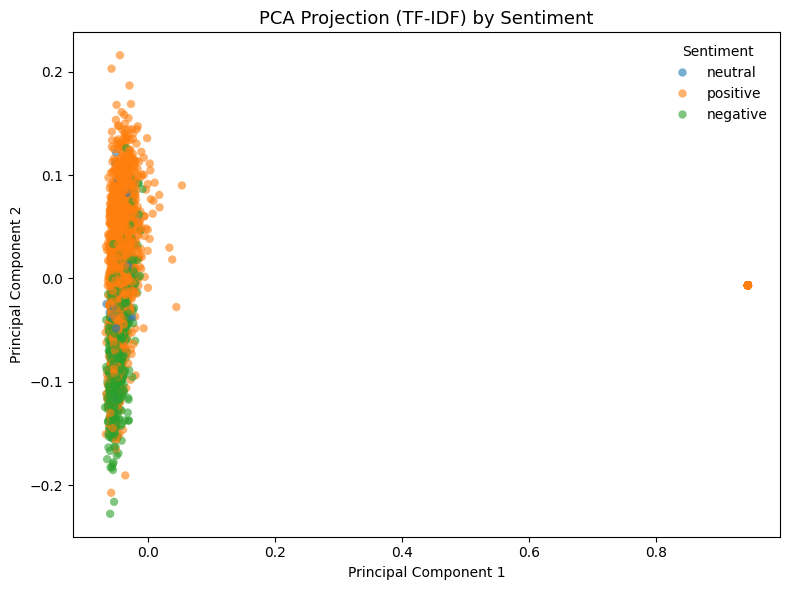

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=train["sentiment"],
    
    alpha=0.6,
    edgecolor="none"
)
plt.title("PCA Projection (TF-IDF) by Sentiment", fontsize=13)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Sentiment", loc="best", frameon=False)
plt.tight_layout()
plt.grid(False)
plt.show()

# Part 7 - Feature engineering

In [32]:
from sklearn.preprocessing import LabelEncoder

# Initialize the label encoder
label_encoder = LabelEncoder()

# Apply encoding to the "sentiment" column
train["sentiment_encoded"] = label_encoder.fit_transform(train["sentiment"])

# Display the mapping of labels to encoded values
label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

label_encoder

LabelEncoder()

# Part 8 - Training and Testing Division

In [33]:
# Define X (features) and y (target)
X = train["clean_text"]
y = train["sentiment_encoded"]

In [34]:
# Split the dataset — adjust test_size as needed
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split train into train + validation
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_train_raw,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# TF-IDF vectorization — fit only on train, transform val and test
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    stop_words=list(stop_words)
)
X_train_tfidf = vectorizer.fit_transform(X_train_raw)
X_val_tfidf   = vectorizer.transform(X_val_raw)
X_test_tfidf  = vectorizer.transform(X_test_raw)

print("TF-IDF generated:", X_train_tfidf.shape)
print(f"Training set size:   {len(X_train_raw)} records")
print(f"Validation set size: {len(X_val_raw)} records")
print(f"Test set size:       {len(X_test_raw)} records")

TF-IDF generated: (1766, 96313)
Training set size:   1766 records
Validation set size: 442 records
Test set size:       553 records


In [35]:
# Distribution overview
print("\nTraining set distribution:")
print(y_train.value_counts(normalize=True).round(2))

print("\nTest set distribution:")
print(y_test.value_counts(normalize=True).round(2))


Training set distribution:
sentiment_encoded
2    0.70
0    0.28
1    0.02
Name: proportion, dtype: float64

Test set distribution:
sentiment_encoded
2    0.71
0    0.28
1    0.02
Name: proportion, dtype: float64


# Section A) Machine learning

# Part 9 - Machine learning models

KNN → best k=3 | val accuracy=0.8077


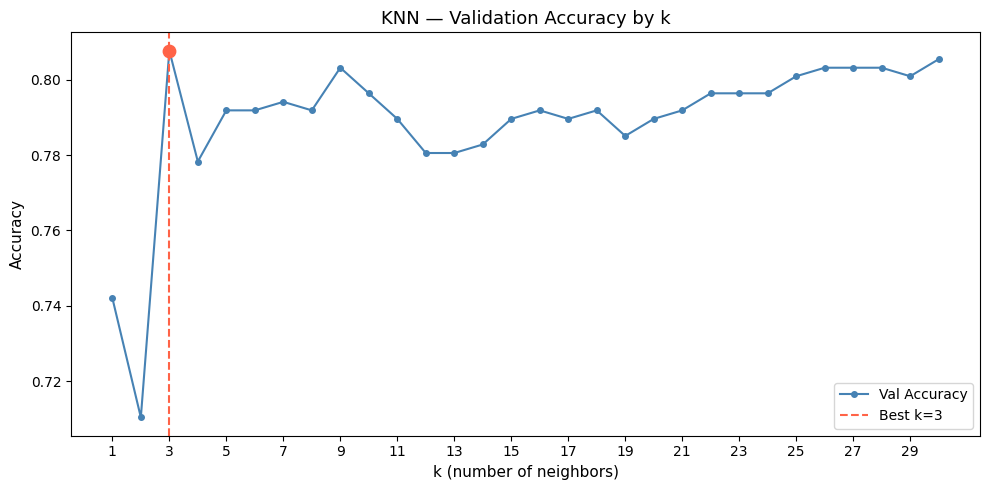

In [36]:
def find_best_k(X_train, y_train, X_val, y_val, k_range=30):
    """
    Finds the best k for KNeighborsClassifier using validation set accuracy.
    Input: X_train, y_train, X_val, y_val (arrays or sparse matrices), k_range (int)
    Output: dict with best k and accuracy scores per k
    """
    k_scores = {}
    for k in range(1, k_range + 1):
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_val, model.predict(X_val))
        k_scores[k] = acc

    best_k = max(k_scores, key=k_scores.get)
    best_acc = k_scores[best_k]

    print(f"KNN → best k={best_k} | val accuracy={best_acc:.4f}")

    return {"best_k": best_k, "best_acc": best_acc, "k_scores": k_scores}


def plot_k_search(k_scores, best_k):
    """
    Plots validation accuracy for each k value in KNN search.
    Input: k_scores (dict {k: accuracy}), best_k (int)
    Output: matplotlib plot
    """
    ks = list(k_scores.keys())
    accs = list(k_scores.values())

    plt.figure(figsize=(10, 5))
    plt.plot(ks, accs, marker='o', linewidth=1.5, markersize=4, color='steelblue', label='Val Accuracy')
    plt.axvline(x=best_k, color='tomato', linestyle='--', linewidth=1.5, label=f'Best k={best_k}')
    plt.scatter([best_k], [k_scores[best_k]], color='tomato', zorder=5, s=80)
    plt.title('KNN — Validation Accuracy by k', fontsize=13)
    plt.xlabel('k (number of neighbors)', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.xticks(ks[::2])
    plt.legend()
    plt.tight_layout()
    plt.show()

knn_result = find_best_k(X_train_tfidf, y_train, X_val_tfidf, y_val, k_range=30)
plot_k_search(knn_result["k_scores"], knn_result["best_k"])

In [37]:
def find_best_depth(X_train, y_train, X_val, y_val, depth_range=30):
    """
    Finds the best max_depth for DecisionTreeClassifier using validation set accuracy.
    Input: X_train, y_train, X_val, y_val (arrays or sparse matrices), depth_range (int)
    Output: dict with best depth and accuracy scores per depth
    """
    depth_scores = {}
    for depth in range(1, depth_range + 1):
        model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        acc = accuracy_score(y_val, model.predict(X_val))
        depth_scores[depth] = acc

    best_depth = max(depth_scores, key=depth_scores.get)
    best_acc = depth_scores[best_depth]

    print(f"DecisionTree → best depth={best_depth} | val accuracy={best_acc:.4f}")

    return {"best_depth": best_depth, "best_acc": best_acc, "depth_scores": depth_scores}


def plot_depth_search(depth_scores, best_depth):
    """
    Plots validation accuracy for each max_depth value in DecisionTree search.
    Input: depth_scores (dict {depth: accuracy}), best_depth (int)
    Output: matplotlib plot
    """
    depths = list(depth_scores.keys())
    accs = list(depth_scores.values())

    plt.figure(figsize=(10, 5))
    plt.plot(depths, accs, marker='s', linewidth=1.5, markersize=4, color='seagreen', label='Val Accuracy')
    plt.axvline(x=best_depth, color='tomato', linestyle='--', linewidth=1.5, label=f'Best depth={best_depth}')
    plt.scatter([best_depth], [depth_scores[best_depth]], color='tomato', zorder=5, s=80)
    plt.title('Decision Tree — Validation Accuracy by max_depth', fontsize=13)
    plt.xlabel('max_depth', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.xticks(depths[::2])
    plt.legend()
    plt.tight_layout()
    plt.show()

DecisionTree → best depth=12 | val accuracy=0.7783


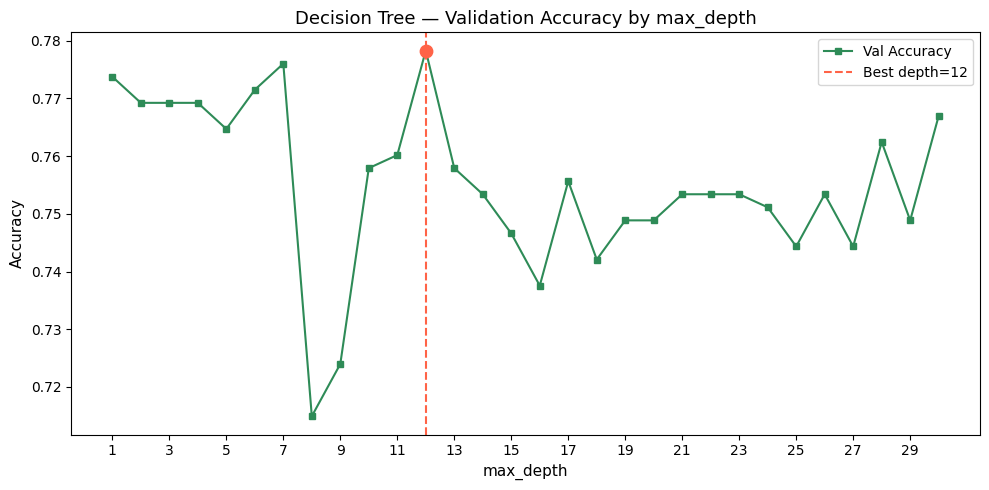

In [38]:
depth_result = find_best_depth(X_train_tfidf, y_train, X_val_tfidf, y_val, depth_range=30)
plot_depth_search(depth_result["depth_scores"], depth_result["best_depth"])

In [39]:
# Define the machine learning models
models = {"MultinomialNB": MultinomialNB(),
          "BernoulliNB": BernoulliNB(),
          "LinearSVC": LinearSVC(),
          "LogisticRegression": LogisticRegression(max_iter=1000, solver="lbfgs"),
          "SGDClassifier": SGDClassifier(max_iter=1000, tol=1e-3, random_state=42),
          "KNN": KNeighborsClassifier(n_neighbors=knn_result["best_k"], metric='manhattan'),
          "DecisionTree": DecisionTreeClassifier(max_depth=depth_result["best_depth"], random_state=42),
          "RandomForest": RandomForestClassifier(n_estimators=200, random_state=42),
          "XGBoost": XGBClassifier(n_estimators=300,learning_rate=0.1,max_depth=6,subsample=0.8,colsample_bytree=0.8,random_state=42,use_label_encoder=False,eval_metric="mlogloss"),
          "LightGBM": LGBMClassifier(n_estimators=300,learning_rate=0.1,num_leaves=31,random_state=42, verbose=-1)}

# Initialize the results list
results = []

# Training loop with progress bar
for name, model in tqdm(models.items(),
                        desc="Training ML models",
                        total=len(models),
                        ncols=100):

    # Train model
    model.fit(X_train_tfidf, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf)

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    # Store results
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "F1-Score": round(f1, 4)
    })

    tqdm.write(f"{name:20s} | Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

Training ML models:  30%|█████████████▏                              | 3/10 [00:00<00:00, 20.44it/s]

MultinomialNB        | Accuracy: 0.7089 | F1-Score: 0.5917
BernoulliNB          | Accuracy: 0.7161 | F1-Score: 0.6080
LinearSVC            | Accuracy: 0.8571 | F1-Score: 0.8479


Training ML models:  30%|█████████████▏                              | 3/10 [00:03<00:00, 20.44it/s]

LogisticRegression   | Accuracy: 0.8228 | F1-Score: 0.8004
SGDClassifier        | Accuracy: 0.8608 | F1-Score: 0.8525


Training ML models:  60%|██████████████████████████▍                 | 6/10 [00:04<00:03,  1.26it/s]

...

RandomForest         | Accuracy: 0.8174 | F1-Score: 0.7996


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [20:29:20] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Training ML models:  90%|███████████████████████████████████████▌    | 9/10 [02:54<00:42, 42.83s/it]

XGBoost              | Accuracy: 0.8716 | F1-Score: 0.8642


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Training ML models: 100%|███████████████████████████████████████████| 10/10 [03:00<00:00, 18.00s/it]

LightGBM             | Accuracy: 0.8662 | F1-Score: 0.8591


Calculating feature importance:   0%|                                        | 0/10 [00:00<?, ?it/s]

MultinomialNB does not have a feature importance attribute (skipping).
BernoulliNB does not have a feature importance attribute (skipping).
KNN does not have a feature importance attribute (skipping).


Calculating feature importance: 100%|███████████████████████████████| 10/10 [00:00<00:00, 13.35it/s]
/tmp/ipykernel_57/3835118498.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x="importance", y="feature", palette="Blues_r")


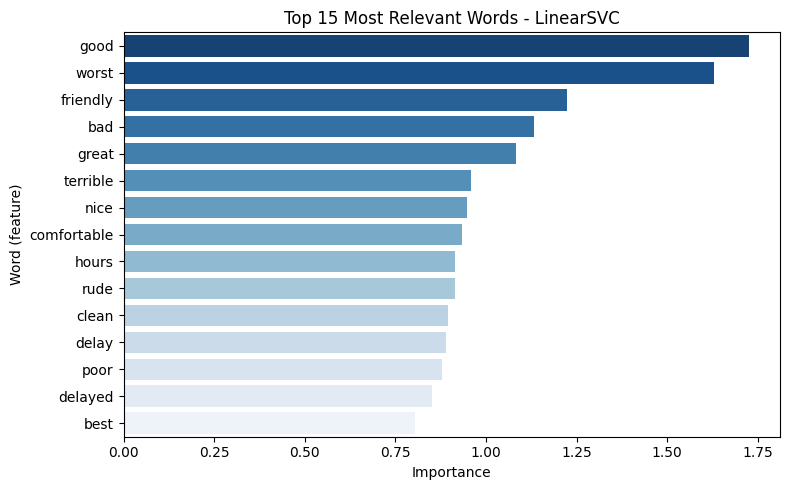

/tmp/ipykernel_57/3835118498.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x="importance", y="feature", palette="Blues_r")


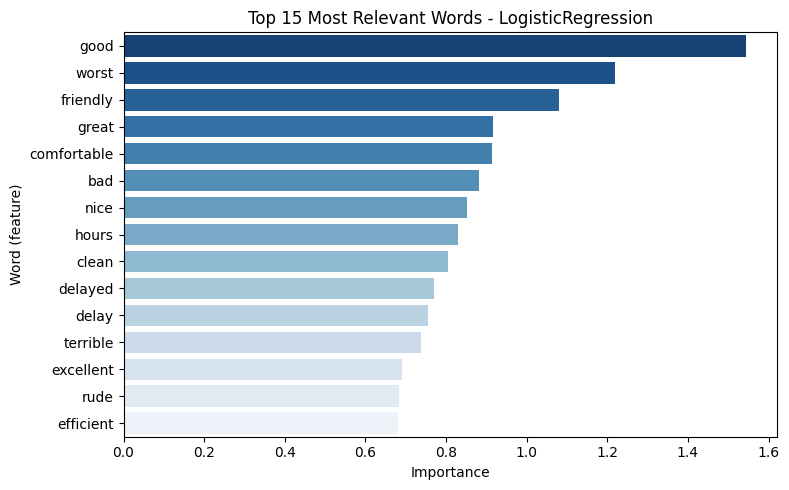

/tmp/ipykernel_57/3835118498.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x="importance", y="feature", palette="Blues_r")


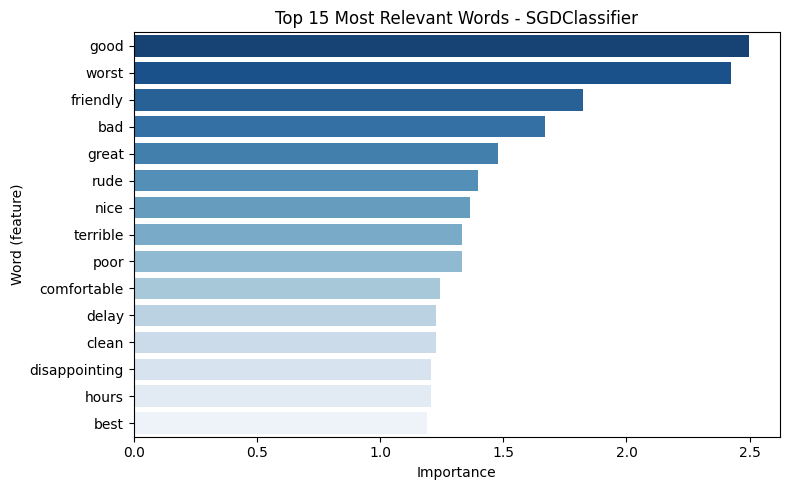

/tmp/ipykernel_57/3835118498.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x="importance", y="feature", palette="Blues_r")


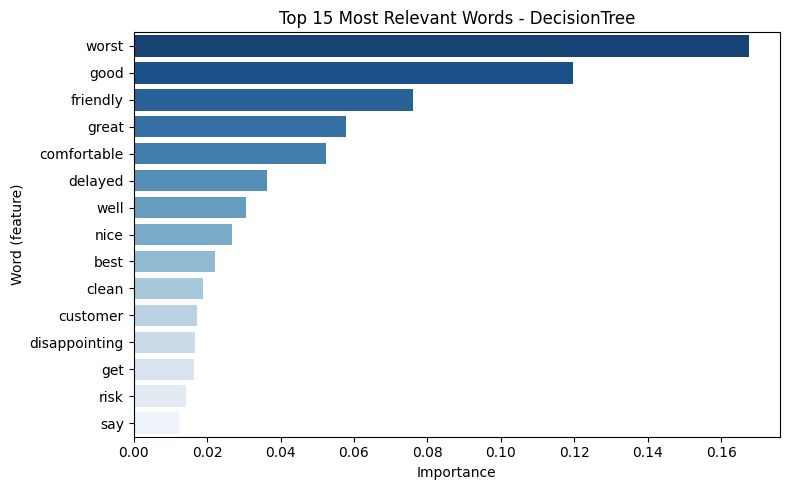

/tmp/ipykernel_57/3835118498.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x="importance", y="feature", palette="Blues_r")


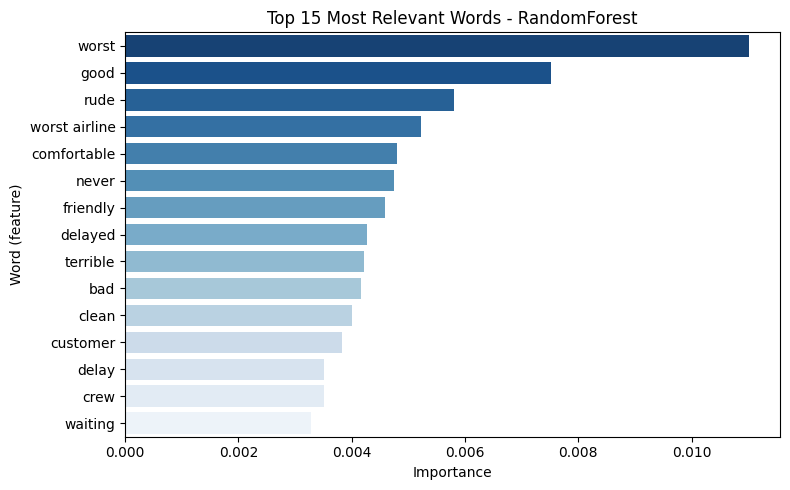

/tmp/ipykernel_57/3835118498.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x="importance", y="feature", palette="Blues_r")


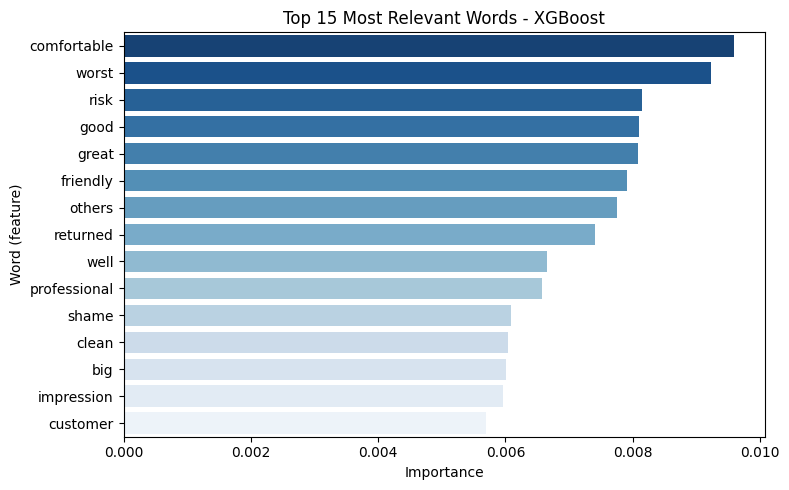

/tmp/ipykernel_57/3835118498.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_imp, x="importance", y="feature", palette="Blues_r")


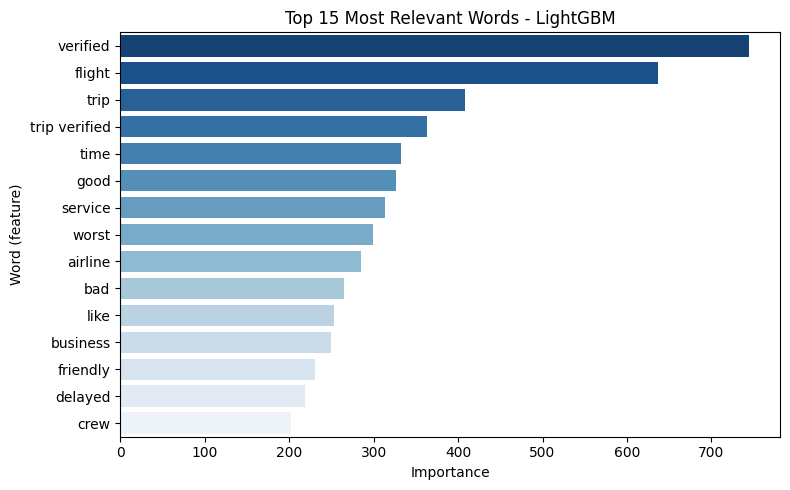

In [40]:
# List of features (TF-IDF words)
feature_names = np.array(vectorizer.get_feature_names_out())

# Dictionary to store feature importances
importances = {}

# Loop through models with progress bar
for name, model in tqdm(models.items(),
                        desc="Calculating feature importance",
                        total=len(models),
                        ncols=100):

    try:
        # Linear models (use coef_)
        if hasattr(model, "coef_"):
            weights = np.abs(model.coef_).mean(axis=0)
            importances[name] = (
                pd.DataFrame({
                    "feature": feature_names,
                    "importance": weights
                })
                .sort_values(by="importance", ascending=False)
                .head(15)
            )

        # Tree-based models (use feature_importances_)
        elif hasattr(model, "feature_importances_"):
            weights = model.feature_importances_
            importances[name] = (
                pd.DataFrame({
                    "feature": feature_names,
                    "importance": weights
                })
                .sort_values(by="importance", ascending=False)
                .head(15)
            )

        else:
            tqdm.write(f"{name} does not have a feature importance attribute (skipping).")

    except Exception as e:
        tqdm.write(f"Error while calculating importance for {name}: {e}")

# Plot top features per model
for name, df_imp in importances.items():
    plt.figure(figsize=(8, 5))
    sns.barplot(data=df_imp, x="importance", y="feature", palette="Blues_r")
    plt.title(f"Top 15 Most Relevant Words - {name}")
    plt.xlabel("Importance")
    plt.ylabel("Word (feature)")
    plt.tight_layout()
    plt.show()

In [41]:
from sklearn.tree import plot_tree

def plot_decision_tree(model, feature_names, class_names, max_depth_plot=3):
    """
    Plots the Decision Tree structure using matplotlib.
    Input: model (fitted DecisionTreeClassifier), feature_names (list), 
           class_names (list), max_depth_plot (int)
    Output: matplotlib plot
    """
    plt.figure(figsize=(20, 8))
    plot_tree(
        model,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        max_depth=max_depth_plot,
        fontsize=9
    )
    plt.title(f'Decision Tree — max_depth={model.get_depth()} (showing top {max_depth_plot} levels)', fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_k_search(k_scores, best_k):
    """
    Plots validation accuracy for each k value in KNN search.
    Input: k_scores (dict {k: accuracy}), best_k (int)
    Output: matplotlib plot
    """
    ks = list(k_scores.keys())
    accs = list(k_scores.values())

    plt.figure(figsize=(10, 5))
    plt.plot(ks, accs, marker='o', linewidth=1.5, markersize=4, color='steelblue', label='Val Accuracy')
    plt.axvline(x=best_k, color='tomato', linestyle='--', linewidth=1.5, label=f'Best k={best_k} (Manhattan)')
    plt.scatter([best_k], [k_scores[best_k]], color='tomato', zorder=5, s=80)
    plt.title('KNN (Manhattan) — Validation Accuracy by k', fontsize=13)
    plt.xlabel('k (number of neighbors)', fontsize=11)
    plt.ylabel('Accuracy', fontsize=11)
    plt.xticks(ks[::2])
    plt.legend()
    plt.tight_layout()
    plt.show()

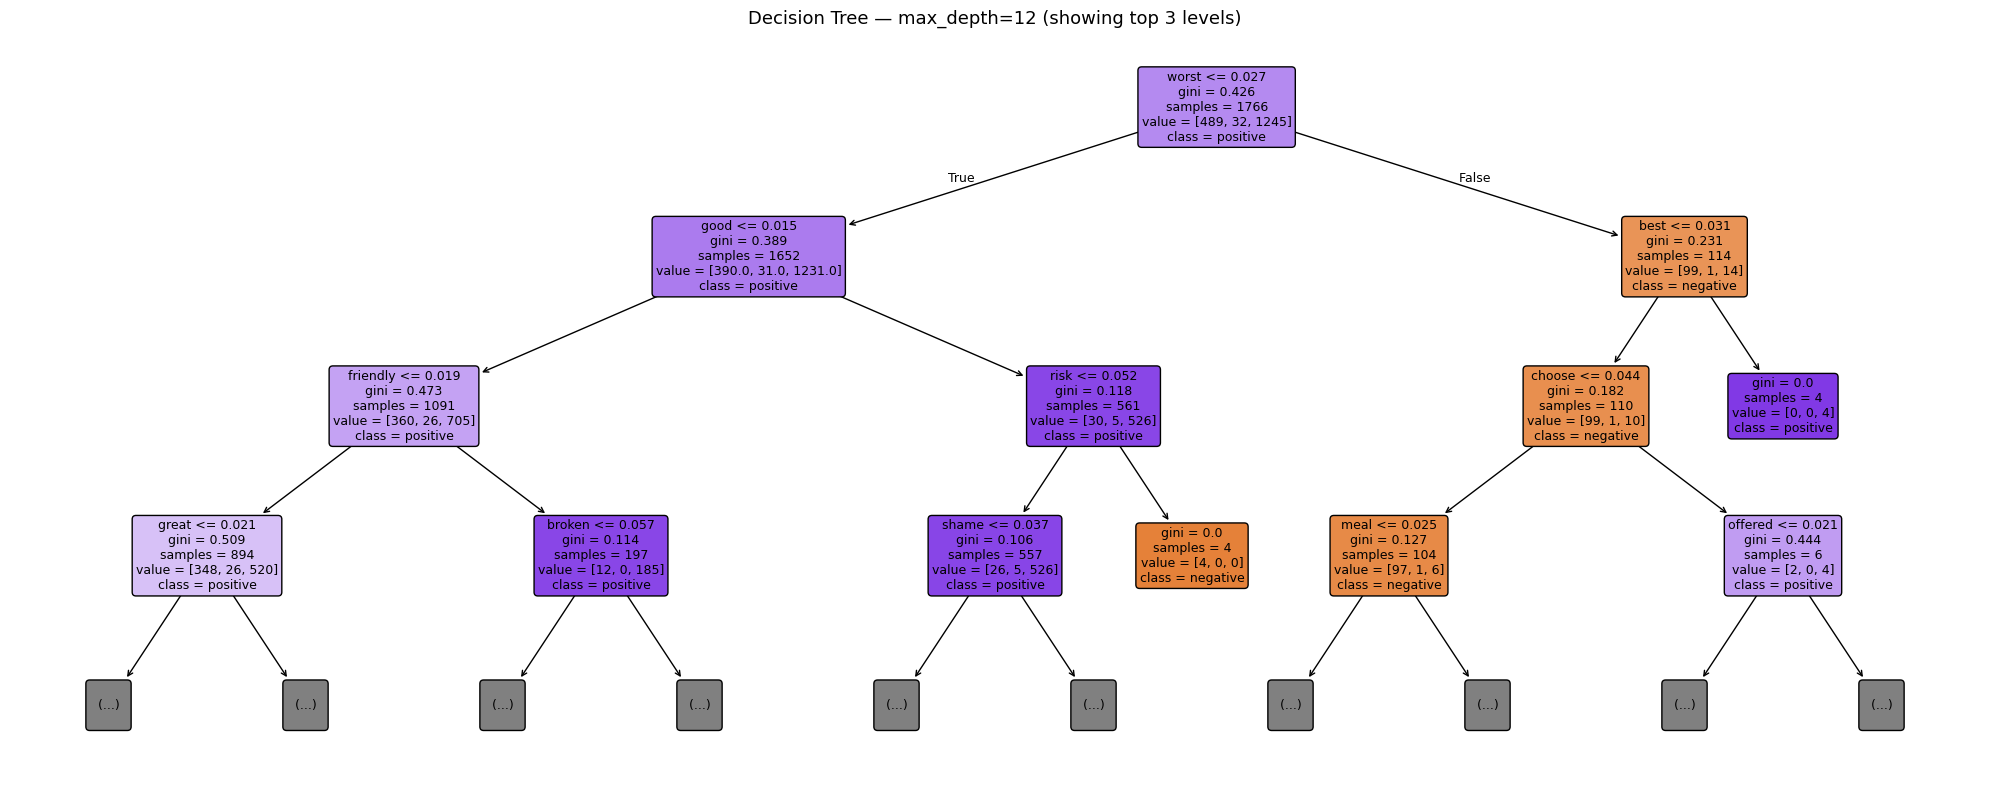

In [42]:
# fit decision tree with best depth — use TF-IDF matrix, not raw text
dt_model = DecisionTreeClassifier(max_depth=depth_result["best_depth"], random_state=42)
dt_model.fit(X_train_tfidf, y_train)

# feature names from TF-IDF vectorizer
feature_names = vectorizer.get_feature_names_out().tolist()
class_names   = [str(c) for c in label_encoder.classes_]

# plot tree
plot_decision_tree(dt_model, feature_names, class_names, max_depth_plot=3)

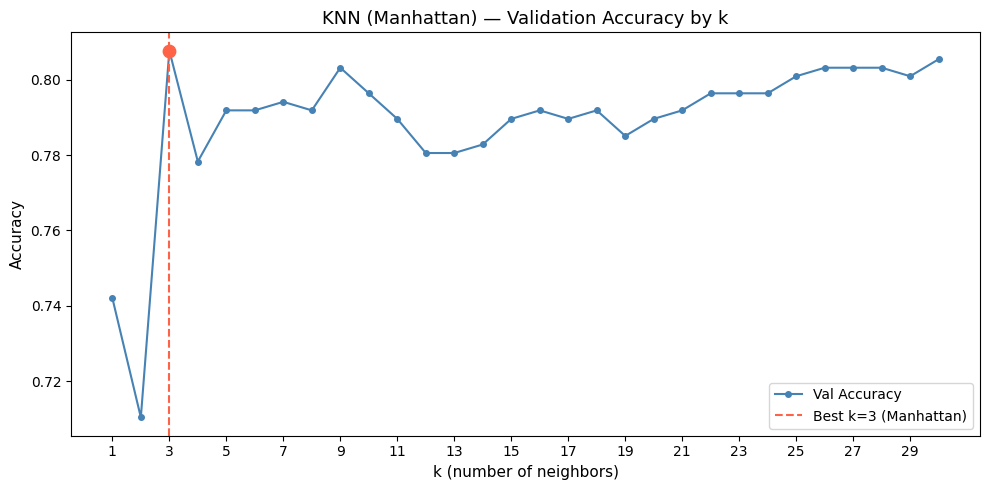

In [43]:
# plot k search
plot_k_search(knn_result["k_scores"], knn_result["best_k"])

# Part 10 - Metrics and Evaluations

In [44]:
# Generate classification reports for each trained model
for name, model in tqdm(models.items(),
                        desc="Generating classification reports",
                        ncols=100):
    try:
        print(f"\n{'='*70}")
        print(f"Classification Report - {name}")
        print(f"{'='*70}\n")

        # Prediction
        y_pred = model.predict(X_test_tfidf)

        # Formatted report
        report = classification_report(y_test, y_pred, digits=3)
        print(report)

    except Exception as e:
        print(f"Error generating report for {name}: {e}")

Generating classification reports:   0%|                                     | 0/10 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, m


Classification Report - MultinomialNB

              precision    recall  f1-score   support

           0      1.000     0.013     0.026       153
           1      0.000     0.000     0.000        10
           2      0.708     1.000     0.829       390

    accuracy                          0.709       553
   macro avg      0.569     0.338     0.285       553
weighted avg      0.776     0.709     0.592       553


Classification Report - BernoulliNB

              precision    recall  f1-score   support

           0      1.000     0.039     0.075       153
           1      0.000     0.000     0.000        10
           2      0.713     1.000     0.832       390

    accuracy                          0.716       553
   macro avg      0.571     0.346     0.303       553
weighted avg      0.779     0.716     0.608       553


Classification Report - LinearSVC

              precision    recall  f1-score   support

           0      0.832     0.680     0.748       153
           1   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
Generating classification reports:  90%|█████████

              precision    recall  f1-score   support

           0      1.000     0.007     0.013       153
           1      0.000     0.000     0.000        10
           2      0.707     1.000     0.828       390

    accuracy                          0.707       553
   macro avg      0.569     0.336     0.280       553
weighted avg      0.775     0.707     0.588       553


Classification Report - DecisionTree

              precision    recall  f1-score   support

           0      0.686     0.471     0.558       153
           1      0.250     0.100     0.143        10
           2      0.804     0.915     0.856       390

    accuracy                          0.778       553
   macro avg      0.580     0.495     0.519       553
weighted avg      0.761     0.778     0.761       553


Classification Report - RandomForest

              precision    recall  f1-score   support

           0      0.814     0.516     0.632       153
           1      0.500     0.100     0.167        

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
Generating classification reports: 100%|████████████████████████████| 10/10 [00:00<00:00, 10.11it/s]

              precision    recall  f1-score   support

           0      0.813     0.739     0.774       153
           1      0.500     0.100     0.167        10
           2      0.886     0.936     0.910       390

    accuracy                          0.866       553
   macro avg      0.733     0.591     0.617       553
weighted avg      0.859     0.866     0.859       553



Generating ROC curves:   0%|                                                 | 0/10 [00:00<?, ?it/s]

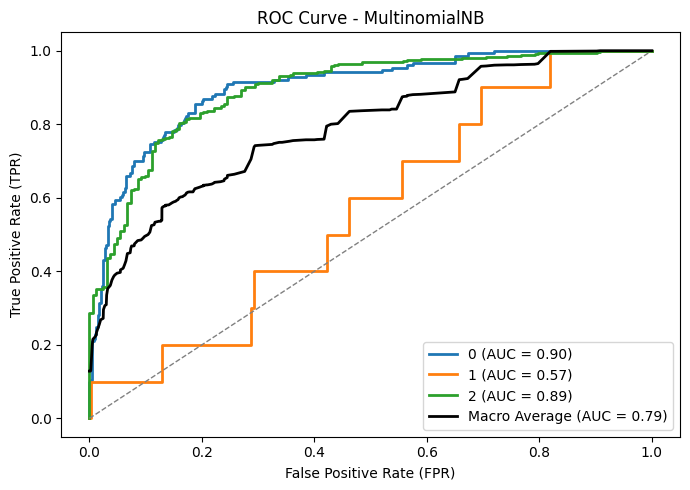

Generating ROC curves:  10%|████                                     | 1/10 [00:00<00:01,  6.03it/s]

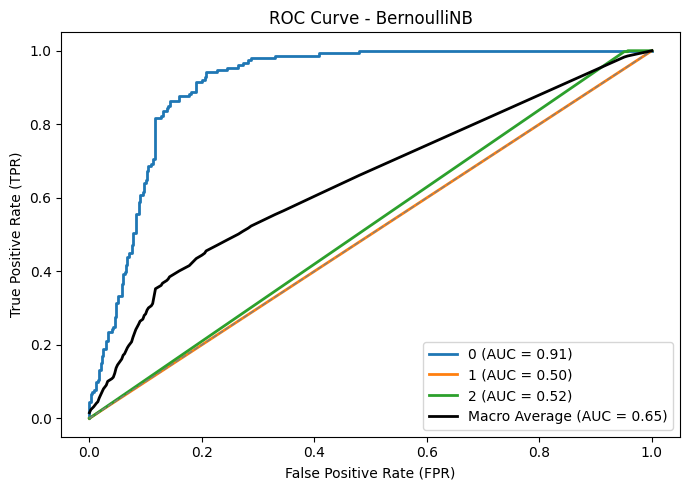

Generating ROC curves:  20%|████████▏                                | 2/10 [00:00<00:01,  5.92it/s]

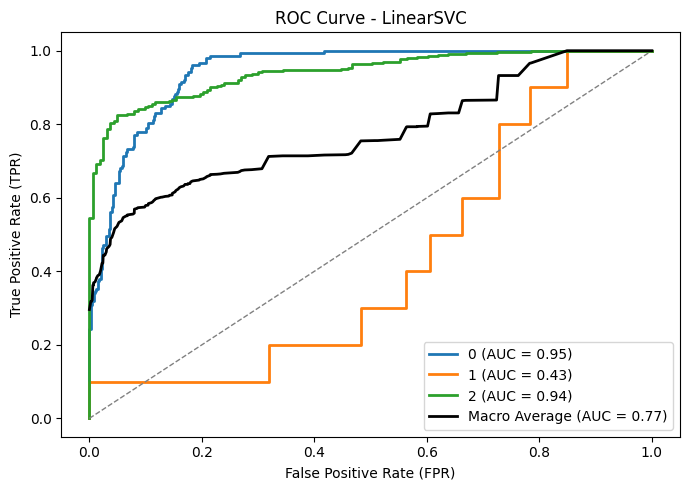

Generating ROC curves:  30%|████████████▎                            | 3/10 [00:00<00:01,  5.96it/s]

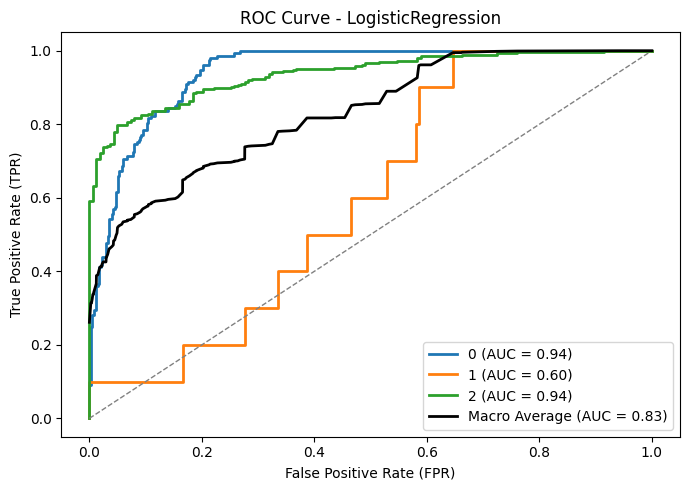

Generating ROC curves:  40%|████████████████▍                        | 4/10 [00:00<00:01,  5.86it/s]

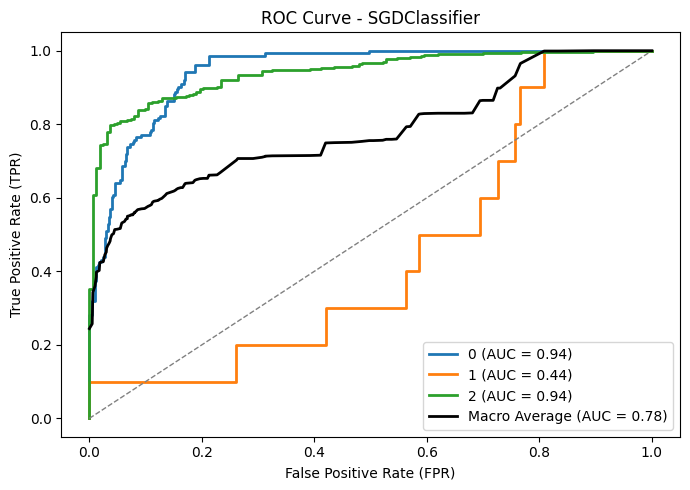

Generating ROC curves:  50%|████████████████████▌                    | 5/10 [00:00<00:00,  5.86it/s]

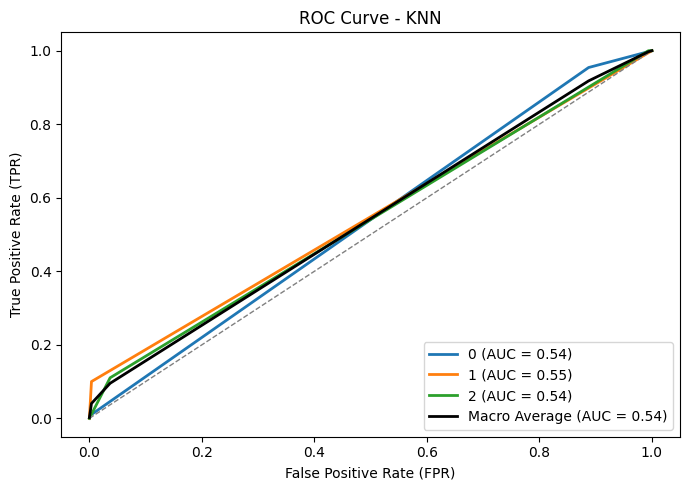

Generating ROC curves:  60%|████████████████████████▌                | 6/10 [00:01<00:01,  3.50it/s]

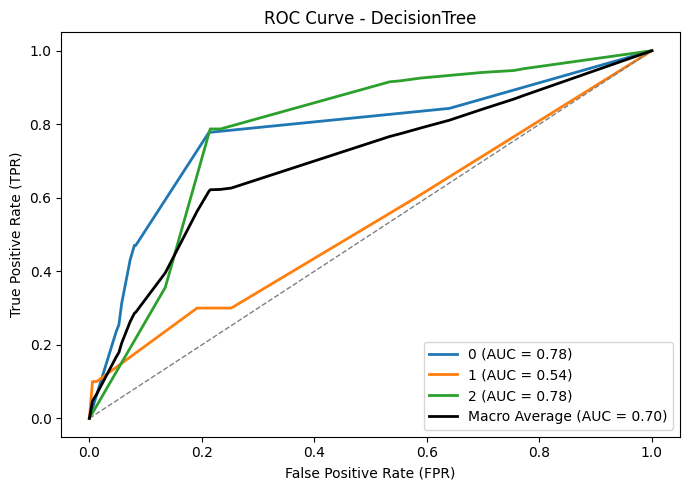

Generating ROC curves:  70%|████████████████████████████▋            | 7/10 [00:01<00:00,  4.01it/s]

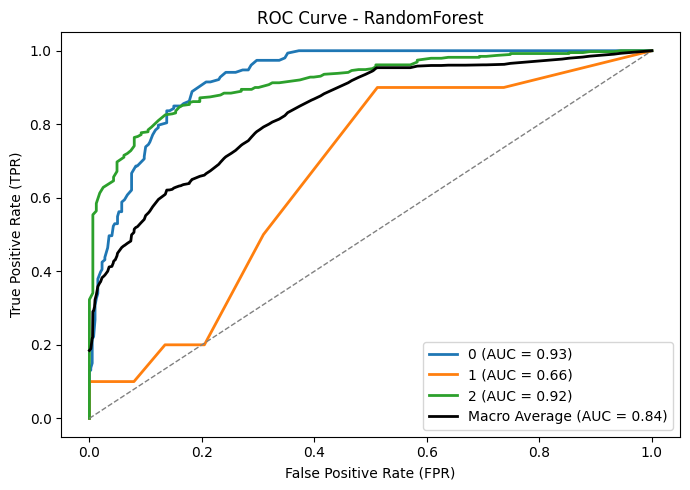

Generating ROC curves:  80%|████████████████████████████████▊        | 8/10 [00:01<00:00,  3.92it/s]

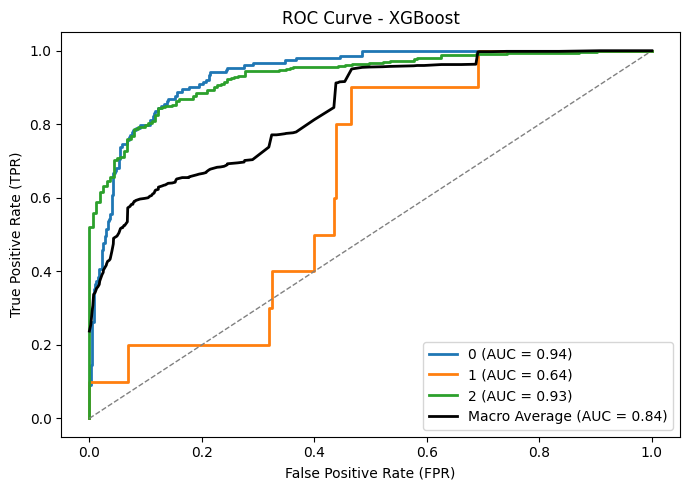

Generating ROC curves:  90%|████████████████████████████████████▉    | 9/10 [00:02<00:00,  4.16it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


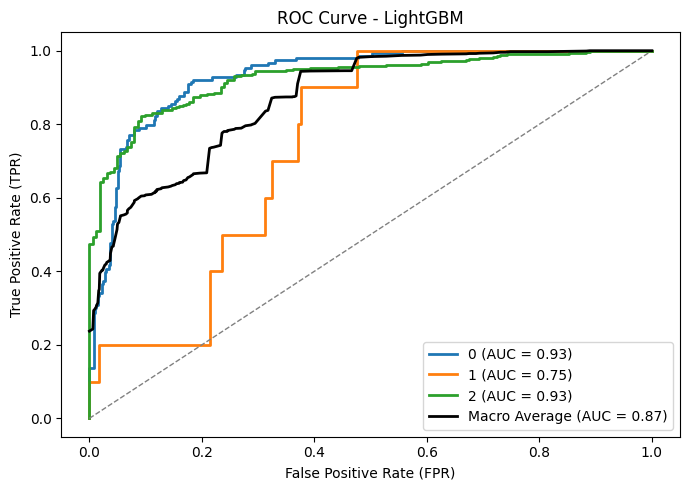

Generating ROC curves: 100%|████████████████████████████████████████| 10/10 [00:02<00:00,  3.79it/s]


In [45]:
# Binarize y_test (One-vs-Rest)
classes = sorted(y_train.unique())  # Example: ["negative", "neutral", "positive"]
y_test_bin = label_binarize(y_test, classes=classes)

for name, model in tqdm(models.items(),
                        desc="Generating ROC curves",
                        ncols=100):
    try:
        # Get prediction scores
        if hasattr(model, "predict_proba"):
            y_score = model.predict_proba(X_test_tfidf)
        elif hasattr(model, "decision_function"):
            y_score = model.decision_function(X_test_tfidf)
        else:
            tqdm.write(f"{name} does not support probability output — skipped.")
            continue

        # Ensure correct shape (1D → 2D)
        if y_score.ndim == 1:
            y_score = np.vstack([1 - y_score, y_score]).T

        # Adjust binary output (2-class case)
        if y_test_bin.shape[1] == 1 and y_score.shape[1] == 2:
            y_test_bin = np.hstack([1 - y_test_bin, y_test_bin])

        # Compute ROC and AUC per class
        fpr, tpr, roc_auc = {}, {}, {}
        for i, cls in enumerate(classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Compute macro-average ROC
        all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
        mean_tpr = np.zeros_like(all_fpr)
        for i in range(len(classes)):
            mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
        mean_tpr /= len(classes)
        roc_auc["macro"] = auc(all_fpr, mean_tpr)

        # Plot ROC curve
        plt.figure(figsize=(7, 5))
        for i, cls in enumerate(classes):
            plt.plot(fpr[i], tpr[i], lw=2, label=f"{cls} (AUC = {roc_auc[i]:.2f})")
        plt.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
        plt.plot(all_fpr, mean_tpr, color="black", lw=2, label=f"Macro Average (AUC = {roc_auc['macro']:.2f})")

        plt.title(f"ROC Curve - {name}")
        plt.xlabel("False Positive Rate (FPR)")
        plt.ylabel("True Positive Rate (TPR)")
        plt.legend(loc="lower right")
        plt.tight_layout()
        plt.grid(False)
        plt.show()

    except Exception as e:
        tqdm.write(f"Error generating ROC curve for {name}: {e}")

Generating confusion matrix (Seaborn):   0%|                                 | 0/10 [00:00<?, ?it/s]

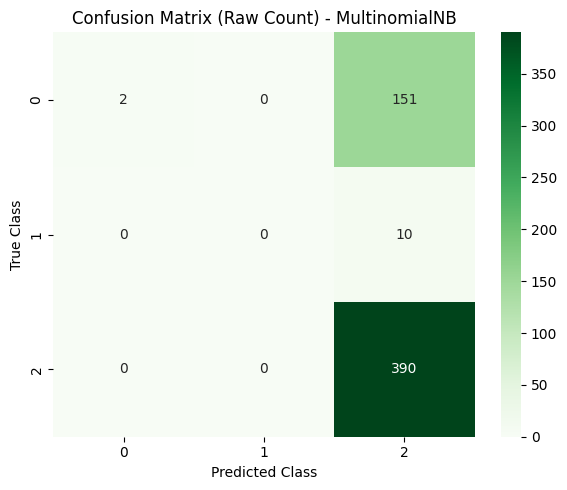

Generating confusion matrix (Seaborn):  10%|██▌                      | 1/10 [00:00<00:01,  5.76it/s]

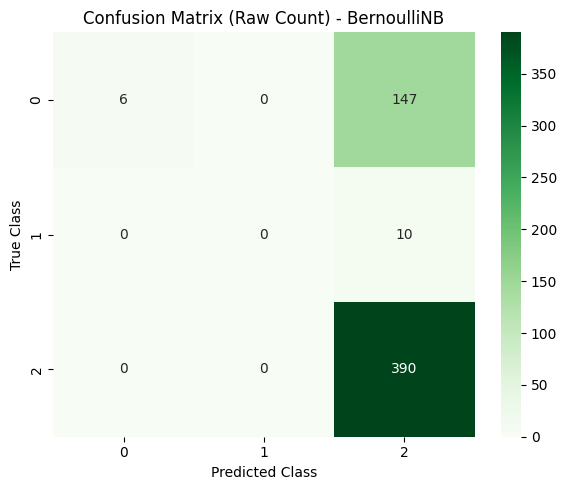

Generating confusion matrix (Seaborn):  20%|█████                    | 2/10 [00:00<00:01,  5.92it/s]

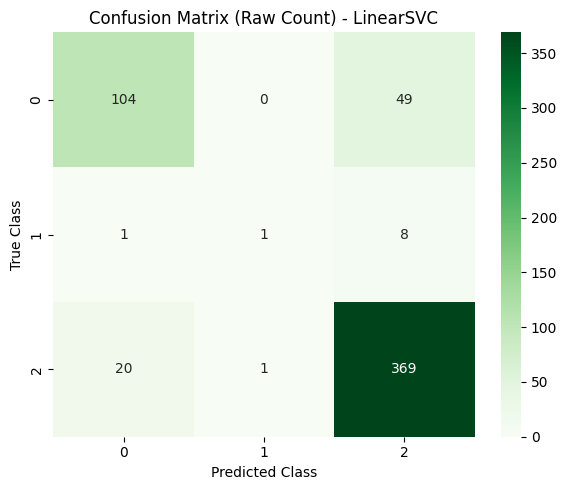

Generating confusion matrix (Seaborn):  30%|███████▌                 | 3/10 [00:00<00:01,  6.07it/s]

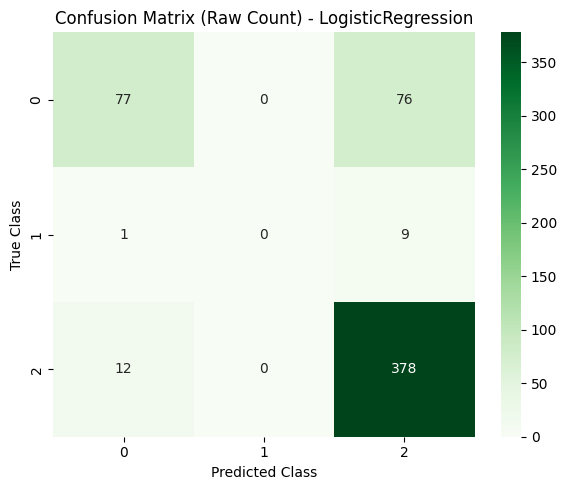

Generating confusion matrix (Seaborn):  40%|██████████               | 4/10 [00:00<00:00,  6.22it/s]

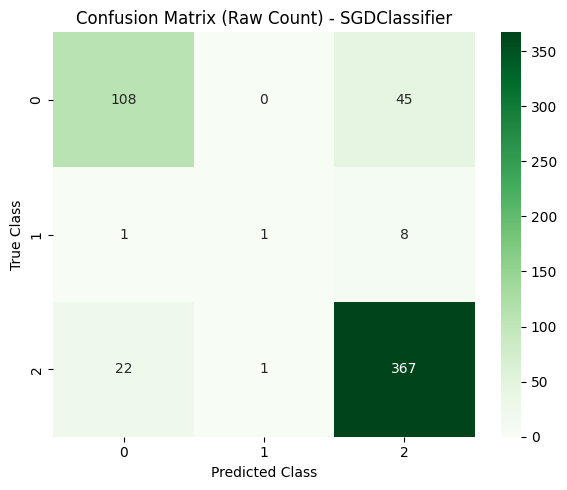

Generating confusion matrix (Seaborn):  50%|████████████▌            | 5/10 [00:00<00:00,  6.26it/s]

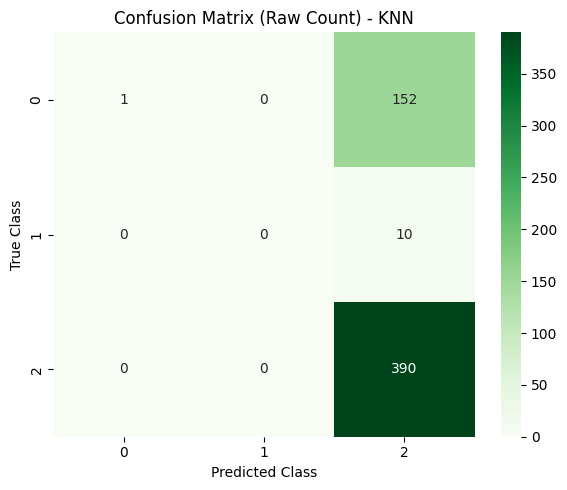

Generating confusion matrix (Seaborn):  60%|███████████████          | 6/10 [00:01<00:01,  3.75it/s]

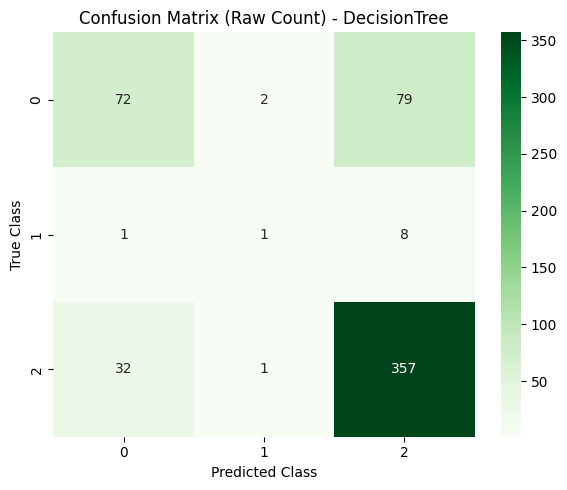

Generating confusion matrix (Seaborn):  70%|█████████████████▌       | 7/10 [00:01<00:00,  4.37it/s]

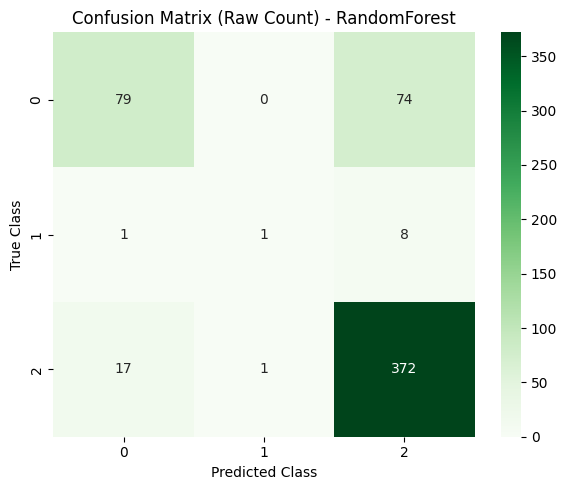

Generating confusion matrix (Seaborn):  80%|████████████████████     | 8/10 [00:01<00:00,  4.32it/s]

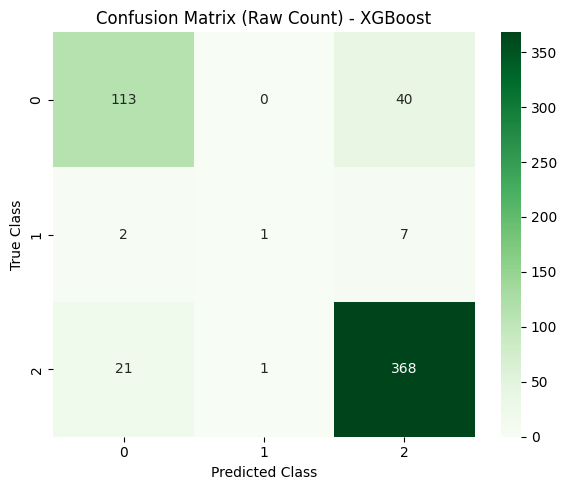

Generating confusion matrix (Seaborn):  90%|██████████████████████▌  | 9/10 [00:01<00:00,  4.45it/s]/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


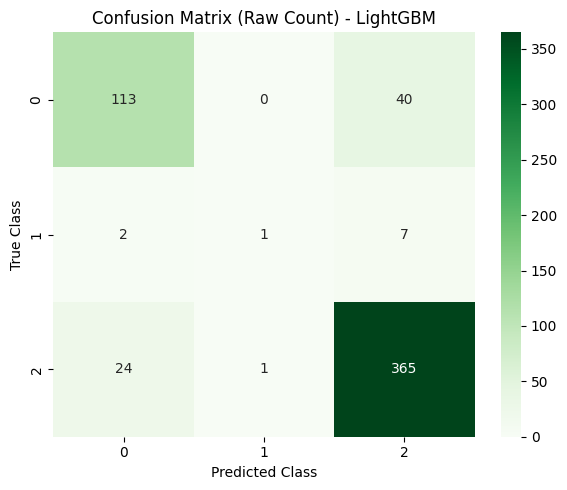

Generating confusion matrix (Seaborn): 100%|████████████████████████| 10/10 [00:02<00:00,  4.56it/s]


In [46]:
# Confusion Matrix

# Define class labels
classes = sorted(y_train.unique())  # Example: ['negative', 'neutral', 'positive']

# Loop through models
for name, model in tqdm(models.items(),
                        desc="Generating confusion matrix (Seaborn)",
                        ncols=100):
    try:
        # Generate predictions
        y_pred = model.predict(X_test_tfidf)

        # Compute confusion matrices (raw and normalized)
        cm = confusion_matrix(y_test, y_pred, labels=classes)
        cm_norm = confusion_matrix(y_test, y_pred, labels=classes, normalize='true')

        # Plot raw confusion matrix (count)
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Greens",
            xticklabels=classes,
            yticklabels=classes
        )
        plt.title(f"Confusion Matrix (Raw Count) - {name}", fontsize=12)
        plt.xlabel("Predicted Class")
        plt.ylabel("True Class")
        plt.tight_layout()
        plt.show()

    except Exception as e:
        tqdm.write(f"Error generating confusion matrix for {name}: {e}")

# **Part 11 - Result model ml final**

In [47]:
# Results Table and Comparison Plot
from sklearn.metrics import precision_score, recall_score

def build_results_dataframe(models, X_test_tfidf, y_test):
    """
    Builds a final results DataFrame with evaluation metrics for all trained models.
    Input: models (dict), X_test_tfidf (sparse matrix), y_test (array)
    Output: DataFrame sorted by F1-Score descending
    """
    records = []

    for name, model in models.items():
        y_pred = model.predict(X_test_tfidf)

        acc       = accuracy_score(y_test, y_pred)
        f1_w      = f1_score(y_test, y_pred, average="weighted")
        f1_macro  = f1_score(y_test, y_pred, average="macro")
        precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
        recall    = recall_score(y_test, y_pred, average="weighted", zero_division=0)

        records.append({
            "Model":              name,
            "Accuracy":           round(acc, 4),
            "Precision (W)":      round(precision, 4),
            "Recall (W)":         round(recall, 4),
            "F1-Score (Weighted)": round(f1_w, 4),
            "F1-Score (Macro)":   round(f1_macro, 4)
        })

    df_results = (
        pd.DataFrame(records)
        .sort_values("F1-Score (Weighted)", ascending=False)
        .reset_index(drop=True)
    )

    df_results.index += 1

    return df_results


df_results = build_results_dataframe(models, X_test_tfidf, y_test)
df_results

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision (W),Recall (W),F1-Score (Weighted),F1-Score (Macro)
1,XGBoost,0.8716,0.8643,0.8716,0.8642,0.6210
2,LightGBM,0.8662,0.8588,0.8662,0.8591,0.6170
3,SGDClassifier,0.8608,0.8534,0.8608,0.8525,0.6111
4,LinearSVC,0.8571,0.8501,0.8571,0.8479,0.6064
5,LogisticRegression,0.8228,0.8125,0.8228,0.8004,0.5067
6,RandomForest,0.8174,0.8122,0.8174,0.7996,0.5601
7,DecisionTree,0.7776,0.7613,0.7776,0.7608,0.5190
8,BernoulliNB,0.7161,0.7795,0.7161,0.6080,0.3026
9,MultinomialNB,0.7089,0.7758,0.7089,0.5917,0.2849
10,KNN,0.7071,0.7749,0.7071,0.5876,0.2803
